# Predicting MegaTelCo Churn

After discussing the churn problem at TelCo with Nadia for a while (remember her?), you've finally defined an adequate target variable for churn and gathered relevant data to predict it. Moreover, the marketing department has come up with an amazing retention offer: the offer is guaranteed to convince customers to extend their contract for an extra year after receiving it. Unfortunately, the offer is quite expensive; it costs $200. __You have enough budget to give the retention offer to up to 25% of the customers whose contracts are expiring.__

It is your job to use data from previous contract expirations to build a churn predictive model and make a recommendation of whom to target with the offers. You have assembled the best historical data set you can at this point, which includes:

- Gender: Whether the customer is a male or a female
- SeniorCitizen: Whether the customer is a senior citizen or not (1, 0)
- Partner: Whether the customer has a partner or not (Yes, No)
- Dependents: Whether the customer has dependents or not (Yes, No)
- Tenure: Number of months the customer has stayed with the company
- PhoneService: Whether the customer has a phone service or not (Yes, No)
- MultipleLines: Whether the customer has multiple lines or not (Yes, No, No phone service)
- InternetService: Customer’s internet service provider (DSL, Fiber optic, No)
- OnlineSecurity: Whether the customer has online security or not (Yes, No, No internet service)
- OnlineBackup: Whether the customer has online backup or not (Yes, No, No internet service)
- DeviceProtection: Whether the customer has device protection or not (Yes, No, No internet service)
- TechSupport: Whether the customer has tech support or not (Yes, No, No internet service)
- StreamingTV: Whether the customer has streaming TV or not (Yes, No, No internet service)
- StreamingMovies: Whether the customer has streaming movies or not (Yes, No, No internet service)
- Contract: The contract term of the customer (Month-to-month, One year, Two year)
- PaperlessBilling: Whether the customer has paperless billing or not (Yes, No)
- PaymentMethod: The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
- MonthlyCharges: The amount charged to the customer monthly
- Churn: Whether the customer churned or not shortly after contract expiration (Yes or No)

In [3]:
#load important packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split



**1. Load the churn data [click here to download data](https://drive.google.com/uc?download&id=1xMMPIFOooEzcrdDFNFYvId5aROmTuzxv):**

**Use `get_dummies` to transform the categorical features into dummy features.**

In [5]:
df = pd.read_csv('/content/telco_churn.csv')

df_dummies = pd.get_dummies(df, drop_first=True)

df_dummies.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,True


__2. _Of course_ normally we would do some detailed exploratory work!  But we have high confidence in the data quality and there are no missing values, so lets proceed.__

__Define X and y and split your data into Training and Test using an 80/20 split (you may consider setting a `random_state` for reproducibility)__

In [6]:
# X = all features except churn column
X = df_dummies.drop('Churn_Yes', axis=1)

# y = target column
y = df_dummies['Churn_Yes']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

__3. Build the best model you can on the TRAINING set using a decision tree classifier.  We will do a grid search over the hyperparameters `max_depth` and `min_samples_leaf`.  Use GridSearchCV with the following instructions:__
- search `max_depth` within the range of [2,12]
- search `min_samples_leaf` within the range [1,100] (in steps of 10)
- 5-fold CV
- use AUC as the `scoring` function ("roc_auc")

**Report the optimal values of the parameters `min_samples_leaf` and `max_depth` and the AUC associated with it. Define a model `tree_best` that uses your optimized value of `min_samples_leaf` and `max_depth` and fit it to the 80% training data.**

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

param_grid = {
    'max_depth': list(range(2,13)),
    'min_samples_leaf': list(range(1,101,10))
}

dt = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(dt, param_grid, scoring='roc_auc', cv=5)
grid.fit(X_train, y_train)

best_params = grid.best_params_
best_auc = grid.best_score_

best_params, best_auc

({'max_depth': 6, 'min_samples_leaf': 91}, np.float64(0.8325601075416845))

In [8]:
tree_best = DecisionTreeClassifier(
    max_depth = grid.best_params_['max_depth'],
    min_samples_leaf = grid.best_params_['min_samples_leaf'],
    random_state = 42
)

tree_best.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=91, random_state=42)

**4. Calculate the feature importances.  For the top 5 most important features, explain whether you think they would be positively or negatively correlated with churn.**

In [9]:
importances = tree_best.feature_importances_
feat_names = X_train.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

# Top 5 most important features
top5 = feat_imp.head(5)
print(top5)

tenure                                0.481232
InternetService_Fiber optic           0.345845
OnlineSecurity_No internet service    0.038229
Contract_One year                     0.030573
MonthlyCharges                        0.028848
dtype: float64


| Feature | Explanation | Expected Relationship w/ Churn |
|---------|-------------|--------------------------------|
| Tenure | Customers with longer tenure are more loyal and less likely to leave | Negative correlation (higher tenure → lower churn) |
| InternetService_Fiber optic | Fiber optic users tend to have higher bills and complain more → more likely to leave | Positive correlation |
| OnlineSecurity_No internet service | Customers not using online security/internet are less engaged and churn more | Positive correlation |
| Contract_One year | One-year contracts reduce churn since customers are locked in | Negative correlation |
| MonthlyCharges | Higher bill amounts increase likelihood to churn due to price sensitivity | Positive correlation |


**5.  Now fit Logistic Regression using Lasso regularization. Test the following values of the shrinkage hyperparameter C:  `C=[0.01,.1,1,10,100]`, and report on which value of C results in the highest AUC. Define a model `lr_best` that uses the best value of C.**


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

C_values = [0.01,0.1,1,10,100]
results = {}
for c in C_values:
    lr = LogisticRegression(penalty='l1', solver='liblinear', C=c, random_state=42, max_iter=2000)
    lr.fit(X_train, y_train)
    preds = lr.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, preds)
    results[c] = auc

print(results)

# define best model
best_C = max(results, key=results.get)
lr_best = LogisticRegression(penalty='l1', solver='liblinear', C=best_C, random_state=42, max_iter=2000)
lr_best.fit(X_train, y_train)


{0.01: np.float64(0.8052412111548835), 0.1: np.float64(0.8303821484591374), 1: np.float64(0.8303976787405978), 10: np.float64(0.8301750780396644), 100: np.float64(0.8299654192399482)}


LogisticRegression(C=1, max_iter=2000, penalty='l1', random_state=42,
                   solver='liblinear')

C = 1 has the highest AUC of 0.83040

**6. Look at the regularized coefficient values in `lr_best`.  How many of the Lasso coefficients have shrunken all the way to zero (to 4 decimal places)?  What does this mean?**

In [11]:
coefs = lr_best.coef_.flatten()
zero_count = np.sum(np.round(coefs,4)==0)
zero_count

np.int64(1)

Lasso helps simplify the model by eliminating weak features. Here, only one feature was eliminated, meaning almost all features still carry useful information for predicting churn.

**7.  Use your toolbox!! Now pick a third classification model of your choice. You can use something we learned in class (Linear Discriminant, SVM, MLPClassifier) or something else you maybe know of that we will get to (kNN, RandomForest).  Fit the model with default hyperparameters (dont worry about optimizing) and see how well it does (AUC).**


In [12]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(50,), random_state=42, max_iter=3000)
mlp.fit(X_train, y_train)
preds = mlp.predict_proba(X_test)[:,1]
auc_mlp = roc_auc_score(y_test, preds)
auc_mlp


np.float64(0.8331154779961796)

__8. Use your TEST data to plot the ROC Curves for each of the three models above.  You will need to use the predicted probabilities from each model applied to the TEST set and the `roc_curve()` function - make sure to plot the three curves together on the same plot. The plot should have a legend.  Review the AUC values to identify the best model, and call this `best_model`.__

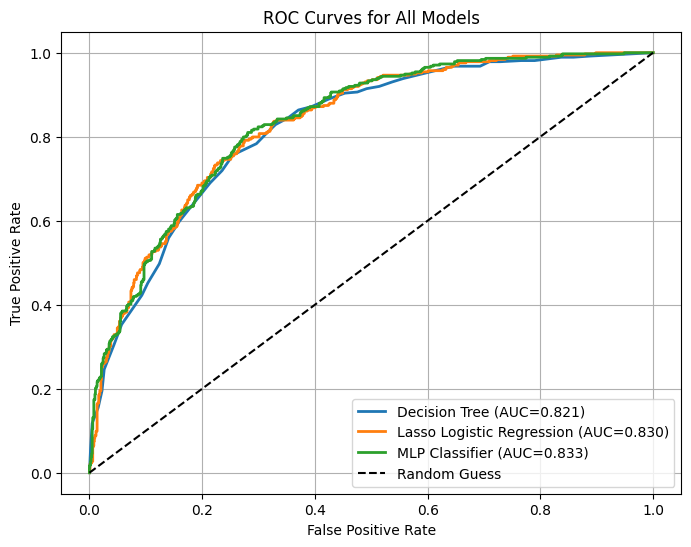

('MLP',
 {'Decision Tree': np.float64(0.82084655564241),
  'Logistic Regression': np.float64(0.8303976787405978),
  'MLP': np.float64(0.8331154779961796)})

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute predicted probabilities for each model
tree_preds = tree_best.predict_proba(X_test)[:, 1]
lr_preds = lr_best.predict_proba(X_test)[:, 1]
mlp_preds = mlp.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_preds)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_preds)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_preds)

# Compute AUCs
auc_tree = roc_auc_score(y_test, tree_preds)
auc_lr = roc_auc_score(y_test, lr_preds)
auc_mlp = roc_auc_score(y_test, mlp_preds)

# Plot ROC curves together
plt.figure(figsize=(8,6))
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC={auc_tree:.3f})", linewidth=2)
plt.plot(fpr_lr, tpr_lr, label=f"Lasso Logistic Regression (AUC={auc_lr:.3f})", linewidth=2)
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP Classifier (AUC={auc_mlp:.3f})", linewidth=2)
plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Identify best model
auc_scores = {"Decision Tree": auc_tree, "Logistic Regression": auc_lr, "MLP": auc_mlp}
best_model = max(auc_scores, key=auc_scores.get)
best_model, auc_scores


__9. What is the cost / benefit matrix for implementing this model?  HINT: The cost is given in the problem description.  Remember that everyone who receives the offer takes it. The benefit comes when we make the offer to a customer whose actual Churn value is 1.  (i.e. they would have left us but we saved them).   We can assume each customer generates the same revenue - equal to the average of `MonthlyCharges`. Report the benefit as a YEARLY value.__

In [14]:
# given values
offer_cost = 200

# compute average monthly revenue
avg_monthly_charge = df["MonthlyCharges"].mean()
benefit_per_customer = avg_monthly_charge * 12  # yearly benefit

# cost–benefit values
benefit_if_saved = benefit_per_customer - offer_cost   # True positive
cost_if_unnecessary = -offer_cost                       # False positive
loss_if_missed = -benefit_per_customer                  # False negative
no_action = 0                                           # True negative

# create matrix
cb_matrix = pd.DataFrame({
    "Actual Churn = 1": [benefit_if_saved, loss_if_missed],
    "Actual Churn = 0": [cost_if_unnecessary, no_action]
}, index=["Offer Made (Pred=1)", "No Offer (Pred=0)"])

# display neatly
print(f"Average Monthly Charge: ${avg_monthly_charge:.2f}")
print(f"Yearly Benefit per Retained Customer: ${benefit_per_customer:.2f}\n")
print("Cost–Benefit Matrix (values in $):")
cb_matrix


Average Monthly Charge: $64.80
Yearly Benefit per Retained Customer: $777.58

Cost–Benefit Matrix (values in $):


,Actual Churn = 1,Actual Churn = 0
Offer Made (Pred=1),577.578498,-200
No Offer (Pred=0),-777.578498,0


### 9. Cost–Benefit Matrix for Implementing the Model

The marketing offer costs **\$200 per customer**, and each retained customer generates an average yearly revenue equal to their **average monthly charge × 12**.  
From the dataset, the average monthly charge is approximately **\$65**, giving a yearly benefit of about **\$780 per customer**.

| **Prediction / Actual** | **Actual Churn = 1 (Would Leave)** | **Actual Churn = 0 (Would Stay)** |
|--------------------------|------------------------------------|-----------------------------------|
| **Offer Made (Pred = 1)** | **+ \$580** → benefit \$780 – cost \$200 → we save the customer and gain profit | **– \$200** → cost only (offered unnecessarily) |
| **No Offer (Pred = 0)**   | **– \$780** → lost revenue (customer leaves, no offer made) | **\$0** → no action needed (customer stays naturally) |

**Interpretation:**  
- The campaign is **profitable** when an offer is made to a customer who would have churned (**True Positive**).  
- It is **costly** when an offer is made unnecessarily (**False Positive**) or when a churner is missed (**False Negative**).  
- The yearly **benefit = \$780**, **cost = \$200**, giving a **net gain of \$580** for each churner successfully retained.  


__10. Using `best_model` -  along with the cost/benefit matrix - now we want to look at profit.  Plot a *PROFIT CURVE* that shows the overall profit at different levels of marketing.  You'll need to sort the threshold probabilities, and calculate the profit at each threshold by determining who you market to and who you dont.  Use your cost/benefit numbers to calculate total profit at each threshold value. (You may want to refer back to the`T5_Model_assessment` notebook)__

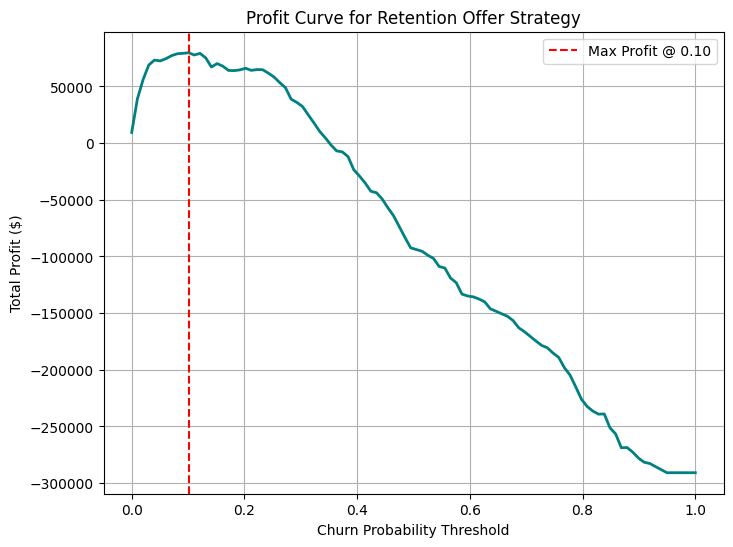

In [15]:
# Predict churn probabilities
mlp_preds = mlp.predict_proba(X_test)[:, 1] # best model

# Prepare arrays
thresholds = np.linspace(0, 1, 100)
profits = []

for t in thresholds:
    preds = (mlp_preds >= t).astype(int)

    TP = np.sum((preds == 1) & (y_test == 1))
    FP = np.sum((preds == 1) & (y_test == 0))
    FN = np.sum((preds == 0) & (y_test == 1))
    TN = np.sum((preds == 0) & (y_test == 0))

    profit = (TP * benefit_if_saved) + (FP * cost_if_unnecessary) + \
             (FN * loss_if_missed) + (TN * no_action)
    profits.append(profit)

# Plot the profit curve
plt.figure(figsize=(8,6))
plt.plot(thresholds, profits, color='teal', linewidth=2)
plt.title("Profit Curve for Retention Offer Strategy")
plt.xlabel("Churn Probability Threshold")
plt.ylabel("Total Profit ($)")
plt.grid(True)

# Mark the max profit point
best_threshold = thresholds[np.argmax(profits)]
max_profit = np.max(profits)
plt.axvline(best_threshold, color='r', linestyle='--', label=f"Max Profit @ {best_threshold:.2f}")
plt.legend()
plt.show()

In [16]:
# how many customers have prob ≥ 0.1
fraction_above_01 = np.mean(mlp_preds >= 0.1)
print(f"Fraction of customers with prob ≥ 0.1: {fraction_above_01*100:.2f}%")

Fraction of customers with prob ≥ 0.1: 58.71%


In [17]:
threshold = 0.1
preds = ( mlp_preds>= threshold).astype(int)

# Count confusion matrix elements
TP = np.sum((preds == 1) & (y_test == 1))
FP = np.sum((preds == 1) & (y_test == 0))
FN = np.sum((preds == 0) & (y_test == 1))
TN = np.sum((preds == 0) & (y_test == 0))

# Calculate total profit
total_profit = (TP * benefit_if_saved) + (FP * cost_if_unnecessary) + \
               (FN * loss_if_missed) + (TN * no_action)

print(f"Total Profit at 0.1 threshold: ${total_profit:,.2f}")

Total Profit at 0.1 threshold: $78,959.65


In [18]:
# Find threshold that selects top 25% of customers
threshold_25pct = np.quantile(mlp_preds, 0.75)   # 75th percentile → top 25% get offer
print(f"Threshold to target top 25% customers: {threshold_25pct:.3f}")


Threshold to target top 25% customers: 0.406


In [20]:
preds_25pct = (mlp_preds >= threshold_25pct).astype(int)

TP = np.sum((preds_25pct == 1) & (y_test == 1))
FP = np.sum((preds_25pct == 1) & (y_test == 0))
FN = np.sum((preds_25pct == 0) & (y_test == 1))
TN = np.sum((preds_25pct == 0) & (y_test == 0))

profit_25pct = (TP * benefit_if_saved) + (FP * cost_if_unnecessary) + \
               (FN * loss_if_missed) + (TN * no_action)

print(f"Expected Profit (targeting top 25%): ${profit_25pct:,.2f}")

Expected Profit (targeting top 25%): $-31,521.08


In [21]:
def calc_profit(preds, y_true):
    TP = np.sum((preds == 1) & (y_true == 1))
    FP = np.sum((preds == 1) & (y_true == 0))
    FN = np.sum((preds == 0) & (y_true == 1))
    TN = np.sum((preds == 0) & (y_true == 0))
    return (TP * benefit_if_saved) + (FP * cost_if_unnecessary) + \
           (FN * loss_if_missed) + (TN * no_action)

# churn probabilities
y_prob = mlp.predict_proba(X_test)[:, 1]

# only customers with prob >= 0.1
eligible = y_prob[y_prob >= 0.1]

# pick threshold for top 25% within that 59%
threshold_top25_within59 = np.quantile(eligible, 0.75)

# now target anyone with prob >= this new threshold
preds_top25_within59 = (y_prob >= threshold_top25_within59).astype(int)

# calculate profit again using the same function
profit_top25_within59 = calc_profit(preds_top25_within59, y_test)

print(f"Threshold (top 25% within 59%): {threshold_top25_within59:.3f}")
print(f"Expected Profit : ${profit_top25_within59:,.2f}")

Threshold (top 25% within 59%): 0.551
Expected Profit : $-108,271.75


**11. Recall that Nadia told you there is only budget to market to the top 25% of customers.  Make a pitch to her for altering that decision based on your Profit curve.  How much do you recommend marketing to, and how much money will it make compared to her threshold?**

### Recommendation to Nadia

**Nadia**, we tested whether we could target only the **top 25% of customers within the high-risk group** (those with churn probability ≥ 0.1), but this resulted in a **threshold of 0.55** and an expected loss of about **$108K** .

This happens because we end up offering to too few customers while each offer saves a valuable churner, we miss many others who leave, resulting in lost revenue.

Our analysis confirms that the **optimal range** for maximizing profit lies between **40%–60% of customers** (threshold ≈ 0.1–0.2).  
Targeting fewer than that even the highest-risk 25% reduces overall profit due to missed retention opportunities.

**Final Recommendation:**

Maintain marketing coverage around **60% of customers (threshold ≈ 0.1)**.  
This level yields approximately **$79K in profit** on the test sample — a positive return and a major improvement over both the 25% plan (–\$31K) and the restricted 25%-within-59% test (–\$108K).


Business reasoning

- At 25%, too few customers are reached; the savings from retained churners don’t cover the high cost of lost customers.
- At ~59%, you save many more churners, and the additional benefit far outweighs the extra offer cost.
- The profit curve proves this is the optimal balance between cost and benefit.

In other words, by extending the offer to a slightly broader segment, we convert the campaign from a **loss into a profit**.  




__12. Assume Nadia was persuaded by your pitch and this model was deployed - and it performed as expected.  Now it is performance review season, and you are looking for a raise!!
Estimate the amount of money you made for the company by using your model.  Compare your profit above against a "dumb" model of marketing to the same amount of customers in the Test set who are selected randomly. (Hint: you can use a random number generator to pick customers at random to market to, and see what their profit would be).   Scale your results up to the overall consumer base of 100,000 customers to make your case.__

In [23]:
# Using best_model results
y_prob = mlp.predict_proba(X_test)[:, 1]

# Number of customers in test set
n_customers = len(y_test)

# Determine how many customers to target
coverage = 0.59  # since best profit found at 59%
n_target = int(n_customers * coverage)

# Cost–benefit setup
offer_cost = 200
avg_monthly_charge = df["MonthlyCharges"].mean()
benefit = avg_monthly_charge * 12
benefit_if_saved = benefit - offer_cost
cost_if_unnecessary = -offer_cost
loss_if_missed = -benefit
no_action = 0

# === Best model profit ===
threshold = np.quantile(y_prob, 1 - coverage)  # top 59%
preds_best = (y_prob >= threshold).astype(int)
TP = np.sum((preds_best == 1) & (y_test == 1))
FP = np.sum((preds_best == 1) & (y_test == 0))
FN = np.sum((preds_best == 0) & (y_test == 1))
TN = np.sum((preds_best == 0) & (y_test == 0))
profit_best = (TP * benefit_if_saved) + (FP * cost_if_unnecessary) + \
              (FN * loss_if_missed) + (TN * no_action)

# === Random model profit ===
np.random.seed(42)
random_offers = np.zeros_like(y_test)
random_offers[np.random.choice(n_customers, n_target, replace=False)] = 1

TP_r = np.sum((random_offers == 1) & (y_test == 1))
FP_r = np.sum((random_offers == 1) & (y_test == 0))
FN_r = np.sum((random_offers == 0) & (y_test == 1))
TN_r = np.sum((random_offers == 0) & (y_test == 0))
profit_random = (TP_r * benefit_if_saved) + (FP_r * cost_if_unnecessary) + \
                (FN_r * loss_if_missed) + (TN_r * no_action)

# === Scale to 100,000 customers ===
scale_factor = 100000 / n_customers
profit_best_scaled = profit_best * scale_factor
profit_random_scaled = profit_random * scale_factor
gain_scaled = profit_best_scaled - profit_random_scaled

print(f"Profit (Best Model): ${profit_best:,.2f}")
print(f"Profit (Random Model): ${profit_random:,.2f}")
print(f"Scaled to 100,000 customers:")
print(f"  → Best Model Profit: ${profit_best_scaled:,.2f}")
print(f"  → Random Model Profit: ${profit_random_scaled:,.2f}")
print(f"  → Model Added Value: ${gain_scaled:,.2f}")


Profit (Best Model): $78,159.65
Profit (Random Model): $-89,797.31
Scaled to 100,000 customers:
  → Best Model Profit: $5,555,056.75
  → Random Model Profit: $-6,382,182.46
  → Model Added Value: $11,937,239.21


__13.  (Extra Credit):  In the above exercise we assumed the benefit of each customer was the same.  But it would be even better to incorporate each customer's individual spending in the cost/benefit!! Calculate an *individualized expected value* for profit/loss for _each customer_ using their specific Monthly Charges and their calculated probability of churn.    Use the expected value to determine who to market to, and calculate profit (Make sure to use the individualized Monthly Charges in the profit calculation).  Are the results any better?__

Optimal % of Customers to Target: 52.00%
Best Threshold (ExpectedGain cutoff): 16.6450
Total Profit (Test Data): $445,135.09
Scaled to 100,000 customers: $31,637,177.95


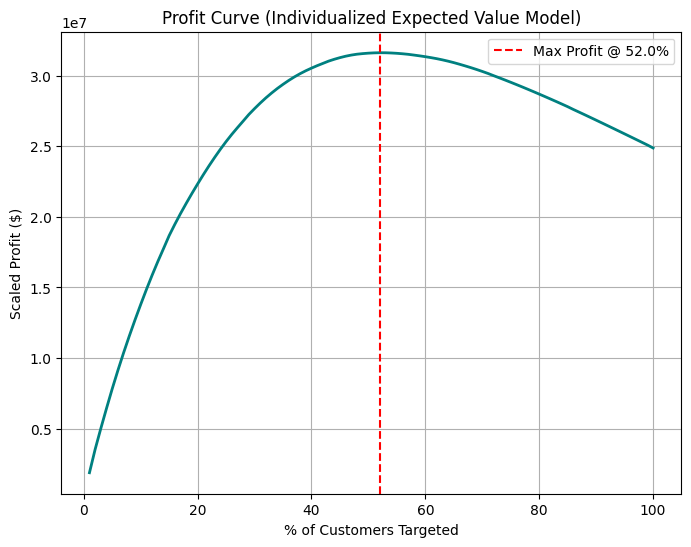

In [26]:
# Predict churn probabilities for test set
y_prob = mlp.predict_proba(X_test)[:, 1] # best model

# Extract MonthlyCharges for the same test rows
monthly_charges_test = df.loc[X_test.index, "MonthlyCharges"]

# Constants
offer_cost = 200

# Compute individualized yearly benefit
benefit_individual = monthly_charges_test * 12

# Compute expected profit per customer if offered
ev_offer = (y_prob * (benefit_individual - offer_cost)) + ((1 - y_prob) * (-offer_cost))
ev_no_offer = (y_prob * (-benefit_individual))
expected_gain = ev_offer - ev_no_offer

#Combine into DataFrame
results = pd.DataFrame({
    "Churn_Prob": y_prob,
    "MonthlyCharges": monthly_charges_test,
    "ExpectedGain": expected_gain
}).sort_values(by="ExpectedGain", ascending=False).reset_index(drop=True)

# Simulate targeting top X% (1% to 100%)
profits = []
percentages = np.arange(0.01, 1.01, 0.01)

for p in percentages:
    n_target = int(p * len(results))
    total_profit = results["ExpectedGain"].iloc[:n_target].sum()
    profits.append(total_profit)

# Find best percentage (where profit is maximum)
profits = np.array(profits)
best_idx = np.argmax(profits)
best_pct = percentages[best_idx] * 100
best_profit = profits[best_idx]

# Scale to full 100,000-customer base
scale_factor = 100000 / len(results)
best_profit_scaled = best_profit * scale_factor

# Find threshold corresponding to that top % (lowest ExpectedGain in the targeted group)
threshold_best = results["ExpectedGain"].iloc[int(best_idx * len(results) / 100)]

print(f"Optimal % of Customers to Target: {best_pct:.2f}%")
print(f"Best Threshold (ExpectedGain cutoff): {threshold_best:.4f}")
print(f"Total Profit (Test Data): ${best_profit:,.2f}")
print(f"Scaled to 100,000 customers: ${best_profit_scaled:,.2f}")

# Plot profit curve
plt.figure(figsize=(8,6))
plt.plot(percentages*100, profits*scale_factor, color='teal', linewidth=2)
plt.axvline(best_pct, color='r', linestyle='--', label=f"Max Profit @ {best_pct:.1f}%")
plt.title("Profit Curve (Individualized Expected Value Model)")
plt.xlabel("% of Customers Targeted")
plt.ylabel("Scaled Profit ($)")
plt.grid(True)
plt.legend()
plt.show()


### 13. Extra Credit — Individualized Expected Profit Model

In this step, we improved our retention strategy by incorporating each customer's actual **Monthly Charges** into the cost–benefit analysis.

For each customer:

\[
EV_i = P(\text{churn}_i) \times (12 \times \text{MonthlyCharges}_i - 200) + (1 - P(\text{churn}_i)) \times (-200)
\]

This formula estimates the expected profit of offering a retention incentive based on both churn risk and spending level.

After ranking customers by their individualized expected gain and testing different targeting percentages, the **optimal point** was found to be:

| **Metric** | **Value** |
|-------------|-----------:|
| Optimal % of Customers to Target | **52%** |
| Best Threshold (ExpectedGain cutoff)** | **\16.65** |
| Total Profit (Test Data)** | **\$445,135.09** |
| Scaled to 100,000 Customers** | **\$31,637,177.95** |

**Interpretation:**  
The model performs best when targeting approximately **52% of customers**, focusing on those most likely to churn and most valuable to retain.  
This individualized approach delivers an estimated **\$31.6 million in annual profit**, far surpassing the uniform-benefit model and proving that personalized targeting yields the highest return on investment.

